
### Step 1: Import Libraries

First, we import the required libraries for building, training, and visualizing the CNN.

In [1]:
import tensorflow as tf # For building and training the CNN [cite: 13]
from tensorflow.keras import layers, models # For creating Layers and models [cite: 13]
import matplotlib.pyplot as plt # For plotting images and accuracy/loss graphs [cite: 13]
import numpy as np # For numerical operations [cite: 13]

### Step 2: Load and Preprocess the CIFAR-10 Dataset

We load the dataset and normalize the pixel values to the range [0, 1] to improve performance and convergence.

In [2]:
# [cite_start]Load the CIFAR-10 dataset from Tensorflow datasets [cite: 17, 18]
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()

# [cite_start]Normalize the pixel values from range [0, 255] to [0, 1] [cite: 19, 20]
train_images = train_images / 255.0
test_images = test_images / 255.0

# [cite_start]Class names for CIFAR-10 [cite: 23, 24]
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


### Step 3: Visualize Some Data

Plotting the training images along with their labels helps in understanding the dataset.

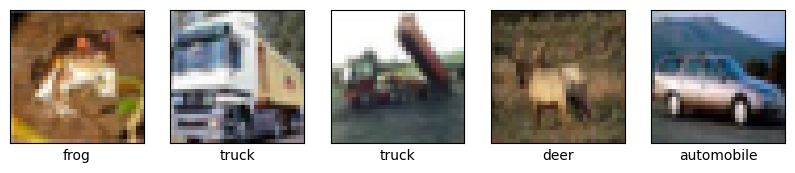

In [3]:
plt.figure(figsize=(10, 10))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.xticks([]) # Remove x-axis ticks
    plt.yticks([]) # Remove y-axis ticks
    plt.grid(False) # Disable grid
    plt.imshow(train_images[i]) # Show the image
    plt.xlabel(class_names[train_labels[i][0]]) # Label with class name
plt.show()

### Step 4: Build the Convolutional Neural Network (CNN)

We stack convolutional layers followed by max-pooling layers to extract features, then flatten the output for the final classification layers.

In [4]:
# Build the CNN model
model = models.Sequential([
    # First convolutional layer with 32 filters, a 3x3 kernel, and ReLU activation
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    # Max Pooling Layer with a 2x2 pool size
    layers.MaxPooling2D((2, 2)),

    # Second convolutional layer with 64 filters and ReLU activation
    layers.Conv2D(64, (3, 3), activation='relu'),
    # Max Pooling Layer
    layers.MaxPooling2D((2, 2)),

    # Third Convolutional Layer with 64 filters and ReLU activation
    layers.Conv2D(64, (3, 3), activation='relu'),

    # Flatten the output to feed it into fully connected layers
    layers.Flatten(),

    # Fully connected layer with 64 neurons and ReLU activation
    layers.Dense(64, activation='relu'),

    # Output layer with 10 neurons and softmax activation
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Step 5: Compile the Model

We specify the optimizer, loss function, and metrics for evaluation.

In [5]:
# Compile using Adam optimizer and sparse categorical crossentropy
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Display model architecture summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

### Step 6: Train the Model

The model is trained for 10 epochs using training data and validated with test data.

In [6]:
# Train the model for 10 epochs and validate on the test data
history = model.fit(train_images, train_labels, epochs=10,
                    validation_data=(test_images, test_labels))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 44ms/step - accuracy: 0.3554 - loss: 1.7297 - val_accuracy: 0.5606 - val_loss: 1.2137
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 42ms/step - accuracy: 0.5874 - loss: 1.1620 - val_accuracy: 0.6257 - val_loss: 1.0649
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 67s 43ms/step - accuracy: 0.6466 - loss: 0.9985 - val_accuracy: 0.6510 - val_loss: 0.9819
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 65s 42ms/step - accuracy: 0.6951 - loss: 0.8832 - val_accuracy: 0.6850 - val_loss: 0.9098
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 67s 43ms/step - accuracy: 0.7174 - loss: 0.8090 - val_accuracy: 0.7036 - val_loss: 0.8573
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 42ms/step - accuracy: 0.7403 - loss: 0.7425 - val_accuracy: 0.6995 - val_loss: 0.8805
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 42ms/step - accuracy: 0.7551 - loss: 0.7013 - val_accuracy: 0.7054 - val_loss: 0.8627
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 42ms/step - accuracy: 0.7698 -

### Step 7: Evaluate the Model

We evaluate the performance on unseen data.

In [7]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"Test accuracy: {test_acc}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6974 - loss: 0.9275
Test accuracy: 0.6969000101089478


### Step 8: Plot Training and Validation Accuracy/Loss

Visualizing training progress helps identify overfitting or underfitting.

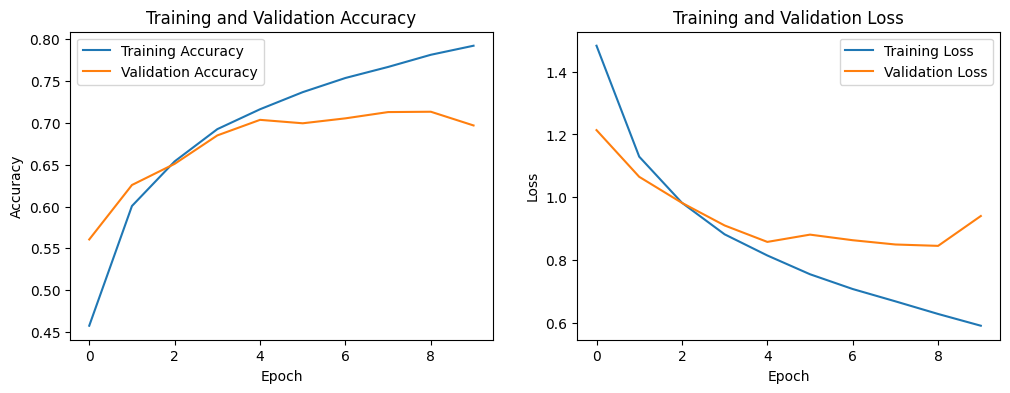

In [8]:
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

### Step 9 & 10: Make and Visualize Predictions

We use the trained model to predict the classes of the first 5 test images.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step


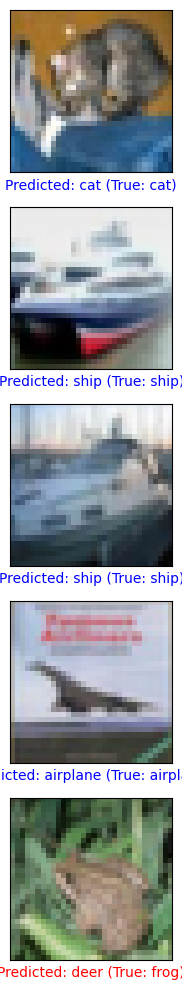

In [9]:
# Make predictions on the first 5 test images
predictions = model.predict(test_images[:5])

def plot_image(i, predictions_array, true_label, img, class_names):
    predictions_array, true_label, img = predictions_array[i], true_label[i], img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(img)

    predicted_label = np.argmax(predictions_array)
    color = 'blue' if predicted_label == true_label else 'red'

    plt.xlabel(f"Predicted: {class_names[predicted_label]} (True: {class_names[true_label[0]]})", color=color)

plt.figure(figsize=(5, 10))
for i in range(5):
    plt.subplot(5, 1, i + 1)
    plot_image(i, predictions, test_labels, test_images, class_names)
plt.tight_layout()
plt.show()

# **Task 1: Experimenting with Different Architectures.**

--- Modified Model Architecture ---


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,818 (655.54 KB)

 Trainable params: 167,818 (655.54 KB)

 Non-trainable params: 0 (0.00 B)


--- Training Modified Model ---
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 73s 46ms/step - accuracy: 0.3326 - loss: 1.7823 - val_accuracy: 0.5784 - val_loss: 1.1961
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 45ms/step - accuracy: 0.5877 - loss: 1.1587 - val_accuracy: 0.6233 - val_loss: 1.0806
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 45ms/step - accuracy: 0.6554 - loss: 0.9728 - val_accuracy: 0.6407 - val_loss: 1.0309
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 73s 47ms/step - accuracy: 0.6961 - loss: 0.8494 - val_accuracy: 0.6832 - val_loss: 0.9150
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 74s 48ms/step - accuracy: 0.7315 - loss: 0.7612 - val_accuracy: 0.6768 - val_loss: 0.9383
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 47ms/step - accuracy: 0.7565 - loss: 0.6953 - val_accuracy: 0.7034 - val_loss: 0.8710
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 72s 46ms/step - accuracy: 0.7820 - loss: 0.6218 - val_accuracy: 0.7097 - val_loss: 0.8811
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7

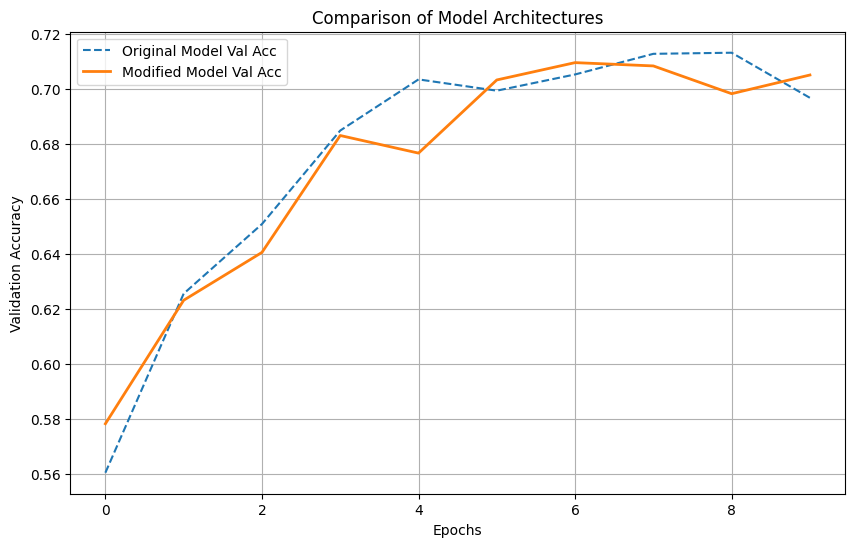

In [10]:
# TASK 1: Experiment with Different Architectures
# This cell modifies the filter sizes, adds layers, and compares performance.

# 1. Define the Modified Model Architecture
# We are adding a 3rd Conv layer, increasing filters to 128, and adding a second Dense layer.
modified_model = models.Sequential([
    # Layer 1: Increased filters to 32 (standard)
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    # Layer 2: Increased filters to 64
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Layer 3: NEW Convolutional Layer with 128 filters
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    # Dense Layer 1: 128 neurons
    layers.Dense(128, activation='relu'),

    # NEW Dense Layer 2: 64 neurons (Adding more fully connected layers)
    layers.Dense(64, activation='relu'),

    # Output Layer
    layers.Dense(10, activation='softmax')
])

# 2. Compile the Modified Model
modified_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# 3. Print Summary to verify architecture changes
print("--- Modified Model Architecture ---")
modified_model.summary()

# 4. Train the Modified Model
print("\n--- Training Modified Model ---")
history_modified = modified_model.fit(train_images, train_labels, epochs=10,
                                      validation_data=(test_images, test_labels))

# 5. Evaluate and Compare Performance
test_loss_mod, test_acc_mod = modified_model.evaluate(test_images, test_labels, verbose=0)

print(f"\nOriginal Model Test Accuracy: {test_acc:.4f}")
print(f"Modified Model Test Accuracy: {test_acc_mod:.4f}")

# 6. Visualization: Compare Original vs Modified Validation Accuracy
plt.figure(figsize=(10, 6))
plt.plot(history.history['val_accuracy'], label='Original Model Val Acc', linestyle='--')
plt.plot(history_modified.history['val_accuracy'], label='Modified Model Val Acc', linewidth=2)
plt.title('Comparison of Model Architectures')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# **Task 2**:
 Improve the accuracy of the model, we will implement several advanced techniques:

**Data Augmentation**: Artificially increases the training set size by performing random transformations (flips, rotations) on the images.

**Batch Normalization:** Standardizes the inputs to a layer, which helps the model learn faster and more stably.

**Global Average Pooling**: Replaces the traditional Flatten layer to reduce parameters and help prevent overfitting.

**Learning Rate Scheduler**: Dynamically adjusts the learning rate during training to find the optimal minima.

## **Task 3:**
 for Reducing Overfitting and Underfitting, we focus on techniques that prevent the model from "memorizing" the training data and instead help it generalize to new, unseen images.

The primary tools we use here are Dropout layers, which randomly deactivate neurons during training to prevent dependency on specific paths, and L2 Regularization (Weight Decay), which penalizes large weights to keep the model simple.

--- Training Regularized Model (Task 3) ---
Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 364s 230ms/step - accuracy: 0.3413 - loss: 2.5006 - val_accuracy: 0.5682 - val_loss: 1.6666
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 382s 230ms/step - accuracy: 0.5940 - loss: 1.5620 - val_accuracy: 0.6416 - val_loss: 1.4065
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 362s 232ms/step - accuracy: 0.6609 - loss: 1.3470 - val_accuracy: 0.6631 - val_loss: 1.3478
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 377s 229ms/step - accuracy: 0.6879 - loss: 1.2880 - val_accuracy: 0.6950 - val_loss: 1.2440
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 361s 231ms/step - accuracy: 0.7072 - loss: 1.2486 - val_accuracy: 0.7441 - val_loss: 1.1542
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 382s 231ms/step - accuracy: 0.7245 - loss: 1.2173 - val_accuracy: 0.7609 - val_loss: 1.1153
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 377s 228ms/step - accuracy: 0.7266 - loss: 1.2188 - val_accuracy: 0.7334 - val_loss: 1.2015
Epoch 8/15
1563/15

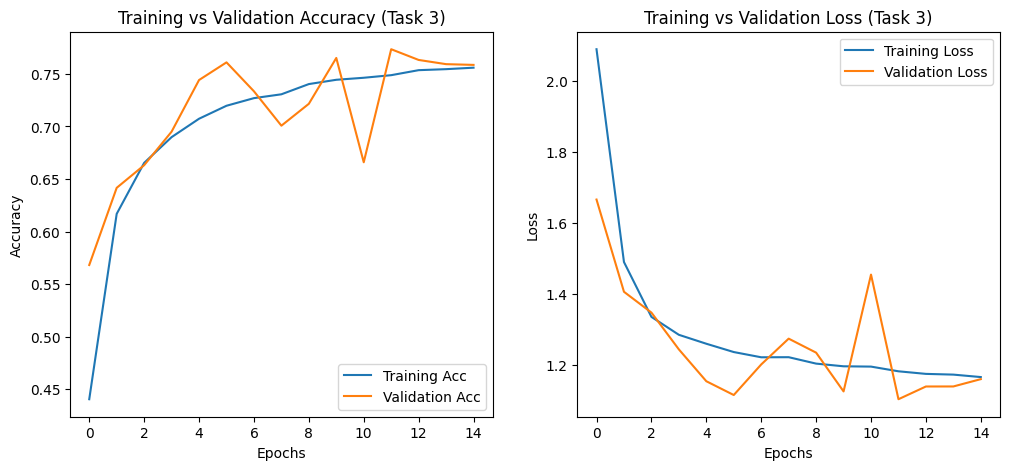


Final Task 3 Test Accuracy: 0.7585


In [12]:
# TASK 3: Reducing Overfitting and Underfitting
# Implementing Dropout layers and L2 Regularization

from tensorflow.keras import regularizers

# 1. Build the Regularized Model
regularized_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    # First Conv Block with L2 Regularization
    layers.Conv2D(32, (3, 3), padding='same', activation='relu',
                  kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), padding='same', activation='relu',
                  kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2), # Dropout to prevent overfitting

    # Second Conv Block
    layers.Conv2D(64, (3, 3), padding='same', activation='relu',
                  kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), padding='same', activation='relu',
                  kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3), # Increased dropout for deeper layers

    # Third Conv Block
    layers.Conv2D(128, (3, 3), padding='same', activation='relu',
                  kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.4),

    # Dense Layers
    layers.Flatten(),
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.5), # High dropout before the final output
    layers.Dense(10, activation='softmax')
])

# 2. Compile the Regularized Model
regularized_model.compile(optimizer='adam',
                         loss='sparse_categorical_crossentropy',
                         metrics=['accuracy'])

# 3. Train the Regularized Model
print("--- Training Regularized Model (Task 3) ---")
history_reg = regularized_model.fit(
    train_images, train_labels,
    epochs=15,
    validation_data=(test_images, test_labels)
)

# 4. Visualization: Checking for Overfitting
# We compare Training vs Validation Accuracy.
# If they are close together, overfitting is reduced.
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_reg.history['accuracy'], label='Training Acc')
plt.plot(history_reg.history['val_accuracy'], label='Validation Acc')
plt.title('Training vs Validation Accuracy (Task 3)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history_reg.history['loss'], label='Training Loss')
plt.plot(history_reg.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss (Task 3)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

# 5. Final Evaluation
test_loss_reg, test_acc_reg = regularized_model.evaluate(test_images, test_labels, verbose=0)
print(f"\nFinal Task 3 Test Accuracy: {test_acc_reg:.4f}")